In [3]:
from sklearn import datasets
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs 
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

<h4> Exercise1: Consider the ecoli data. The goal of this task is to classify the subcellular localization of proteins based on specific features derived from their amino acid sequences. These features represent biochemical and structural properties that can help distinguish where within the cell each protein is most likely to reside.
    
    
- Divide the data into training and test sets (7:3 ratio). 
- Build three classifiers based on Naive Bayes, SVM, and Decision Tree techniques (default parameters or you may specify them). - Additionally, create an ensemble classifier based on these three models. 
- Compare the accuracy of the individual classifiers and the ensemble on the test set. 

In [4]:
# Wczytanie danych z pominięciem pierwszego wiersza (szumu)
df = pd.read_csv("ecoli.txt", index_col=0)
dff = df[~df['class'].isin(["omL","imS",'imL'])]

X = dff.drop(columns=["class"])
y = dff["class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#naive bayes
from sklearn.naive_bayes import GaussianNB 

nb = GaussianNB() #create a model
nb.fit(X_train, y_train); #train model on data

# check how the model works
y_predicted = nb.predict(X_test) #predict species based on test data

# comparison of y_predicted to y_test
x=sum([1 for i in range(len(y_test)) if y_test[i] == y_predicted[i]])/len(y_test) #accuracy on the test set
print(f"Bayes accuracy: {x}")

#svm
sc = StandardScaler()
sc.fit(X_train)

X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

svm = SVC(kernel='linear', C=1, random_state=42)
svm.fit(X_train_std, y_train)

print(f"Svm score: {svm.score(X_test_std, y_test)}") #accuracy

#decision tree

tree = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=0, class_weight='balanced')
tree.fit(X_train, y_train)

print(f'Decision tree score {tree.score(X_test, y_test)}')


#ensemble (hard voting - without probabilities)
ensemble = VotingClassifier(estimators=[
    ('nb', nb),
    ('svm', svm),
    ('tree', tree)
], voting='hard')  #sofr wymaga probalility=True w svm

#train
ensemble.fit(X_train_std, y_train)  # scaled data

print(f'Ensemble classifier accuracy: {ensemble.score(X_test_std, y_test)}')

#comment 
#svm allowed to choose C paramater and data standarisation which helped achieve the best accuracy
#naive bayes assumes feature independece which rarely occurs - worst accracy
#decision trees are suseptible to overfitting (especially in small data samples) - average accuracy
#ensemble connected all models - didnt yield the best accuracy but the model should be more stable

Bayes accuracy: 0.8181818181818182
Svm score: 0.898989898989899
Decision tree score 0.8383838383838383
Ensemble classifier accuracy: 0.8787878787878788


C:\Users\kajaw\AppData\Local\Temp\ipykernel_11748\1689608028.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x=sum([1 for i in range(len(y_test)) if y_test[i] == y_predicted[i]])/len(y_test) #accuracy on the test set


<h4> Exercise2: Consider the headlines dataset, which contains fake news (1298 records) and real news headlines (1968 records), with one headline per line. Apply the Random Forest algorithm to build a classification model. Divide the data into three groups: 70% for the training set, 15% for the validation set, and 15% for the test set. Experiment with different sets of hyperparameters using the validation set. Comment on your results.

In [ ]:
with open('fake.txt', 'r') as file:
    fake = file.read().splitlines() #automatically deletes \n
with open('real.txt', 'r') as file:
    real = file.read().splitlines()

news = fake + real  
y = [0] * len(fake) + [1] * len(real)  # 0-fake, 1-real

#split data: train, test, validation
X_train, X_temp, y_train, y_temp = train_test_split(news, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

#vectorise words
from sklearn.feature_extraction.text import TfidfVectorizer 
tfidf = TfidfVectorizer(max_features = 600) #number of most freaquent words
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_val_tfidf = tfidf.transform(X_val)

#random forest
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(criterion='entropy',
                                 n_estimators=50,
                                 random_state=42, #max depth
                                 class_weight={0: len(fake), 1: len(real)}) 
#calss weight changed to address the imbalance in data:
#in calss. report there were better scores for real news before the change
forest.fit(X_train_tfidf, y_train)
y_val_pred = forest.predict(X_val_tfidf)

#accuracy
from sklearn.metrics import accuracy_score, classification_report
print('Train acuuracy: ', forest.score(X_train_tfidf, y_train)) #to check for overfitting
print('Validation Accuracy: ', forest.score(X_val_tfidf, y_val))
print('Test acuuracy: ', forest.score(X_test_tfidf, y_test))

print('Classification Report: \n', classification_report(y_val, y_val_pred))


#overall the score is quite good, i adjusted max features and n_estimators to account for overfitting

Train acuuracy:  0.9960629921259843
Validation Accuracy:  0.7877551020408163
Test acuuracy:  0.8122448979591836
Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.64      0.71       201
           1       0.78      0.89      0.83       289

    accuracy                           0.79       490
   macro avg       0.79      0.76      0.77       490
weighted avg       0.79      0.79      0.78       490



Exercise3: Consider Gene Expression data. There are four types of the patient condition:

* HC - healthy patients
* STA - stationary patients (medical condition probably isn’t going to improve)
* CR - chronically diseased patients
* RC - recovered patients
    
Propose the top 20 features for differentiating between groups based on:

- F-test / Information Feature Selection (IFS),

- Random Forest (with n_estimators=2000 and max_depth=5).

Are the selected feature subsets similar? Plot boxplot for top1 gene from both approaches.
    
Calculate the Jaccard similarity for 1,2,3,..., 50 features, plot and comment on the results.

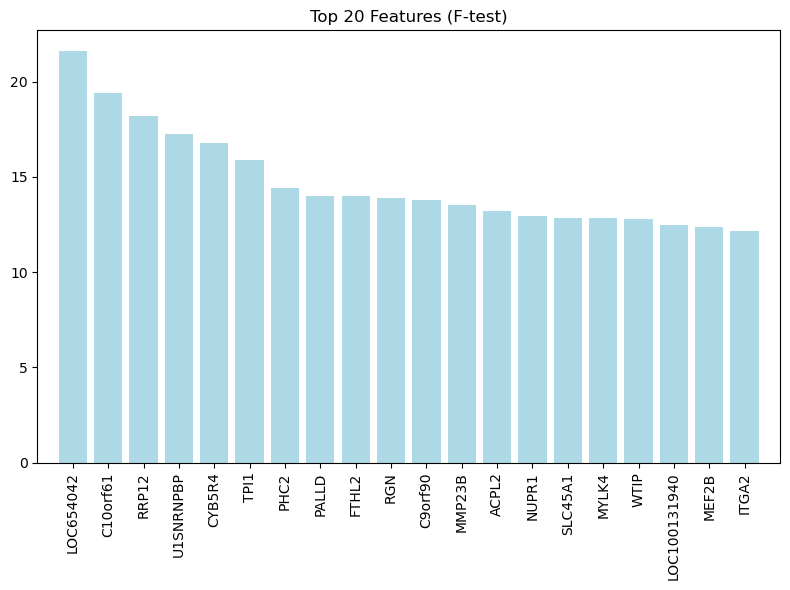

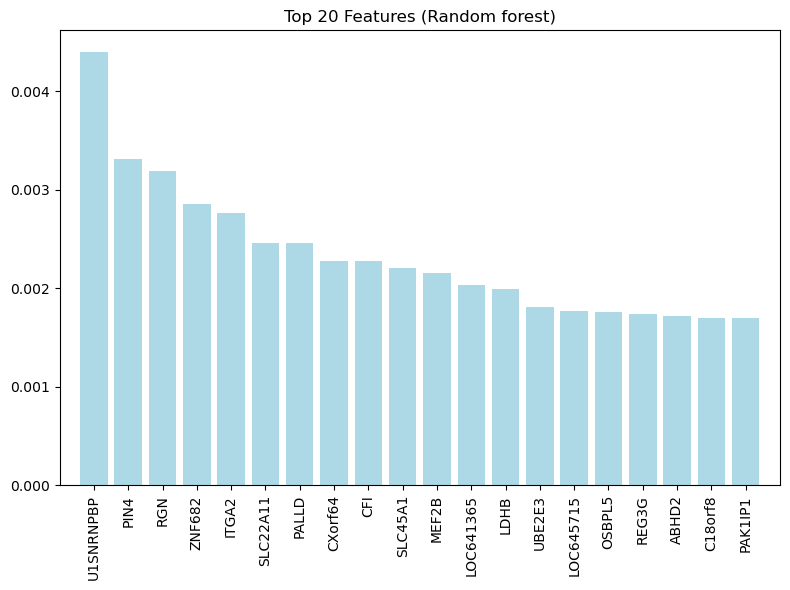

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

annot = pd.read_csv('annotations.csv')
data = pd.read_csv('gene_expression.csv')

# merge data and annotations
data = data.T
data['sample'] = data.index
data = data.merge(annot, 'left').set_index('sample')

# show sample of data
data.head(10)

X_train = data.drop(columns=['group'])
y_train = data['group']

feat_labels = data.columns.tolist()

#f-test
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

scores = selector.scores_  # F-statistics for all features
top = selector.get_support(indices=True)  # indices of selected features
f_indices= top[scores[top].argsort()[::-1]] 

plt.figure(figsize=(8,6))
plt.title('Top 20 Features (F-test)')
plt.bar(range(20), scores[f_indices], color='lightblue', align='center')
plt.xticks(range(20), [feat_labels[i] for i in f_indices], rotation=90)
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

#random forest
forest = RandomForestClassifier(n_estimators=2000, random_state=2)
forest.fit(X_train, y_train)
rf_importances = forest.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.title(f'Top {20} Features (Random forest)')
plt.bar(range(20), rf_importances[rf_indices][:20], color='lightblue', align='center')
plt.xticks(range(20), [feat_labels[i] for i in rf_indices[:20]], rotation=90)
plt.xlim([-1, 20])
plt.tight_layout()
plt.show()

#feature sets are not similar


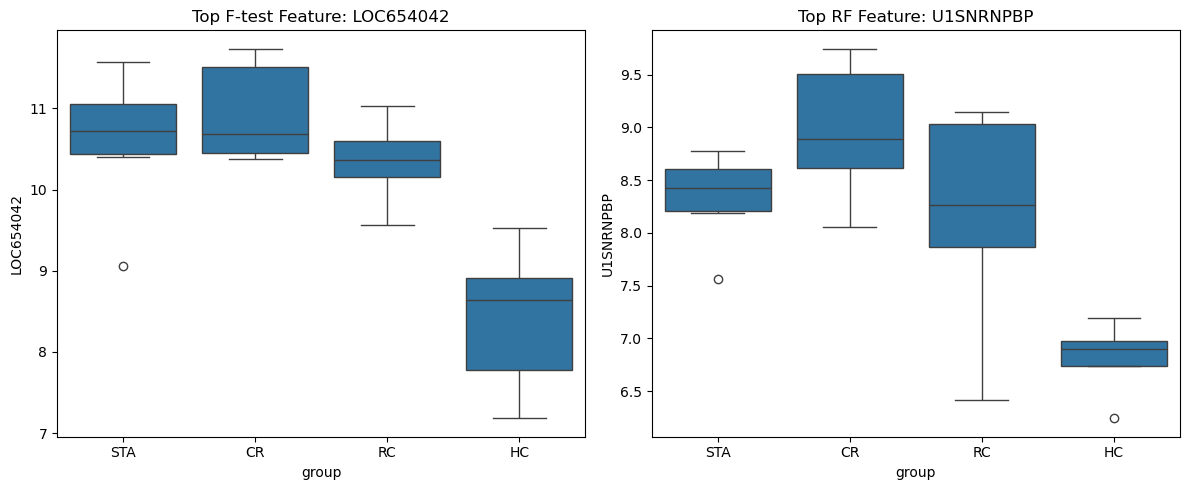

In [10]:
top1_f = feat_labels[f_indices[0]]
top1_rf = feat_labels[rf_indices[0]]

import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=y, y=X[top1_f])
plt.title(f'Top F-test Feature: {top1_f}')

plt.subplot(1, 2, 2)
sns.boxplot(x=y, y=X[top1_rf])
plt.title(f'Top RF Feature: {top1_rf}')

plt.tight_layout()
plt.show()


$\text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|}$

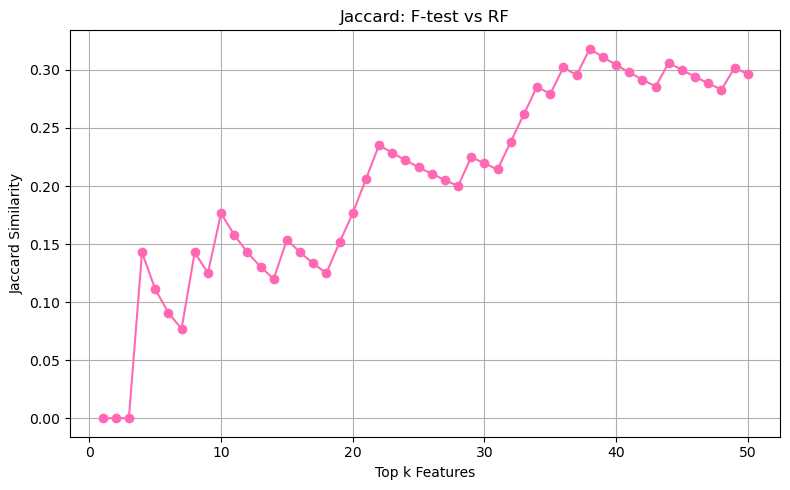

In [11]:
jaccard_scores = []

for k in range(1, 51):
    top_f_set = set(f_indices[:k])
    top_rf_set = set(rf_indices[:k])
    intersection = len(top_f_set.intersection(top_rf_set))
    union = len(top_f_set.union(top_rf_set))
    jaccard = intersection / union
    jaccard_scores.append(jaccard)

# Plot Jaccard scores
plt.figure(figsize=(8, 5))
plt.plot(range(1, 51), jaccard_scores, marker='o', color='hotpink')
plt.xlabel('Top k Features')
plt.ylabel('Jaccard Similarity')
plt.title('Jaccard: F-test vs RF')
plt.grid(True)
plt.tight_layout()
plt.show()